决策树 -- 基尼系数的计算

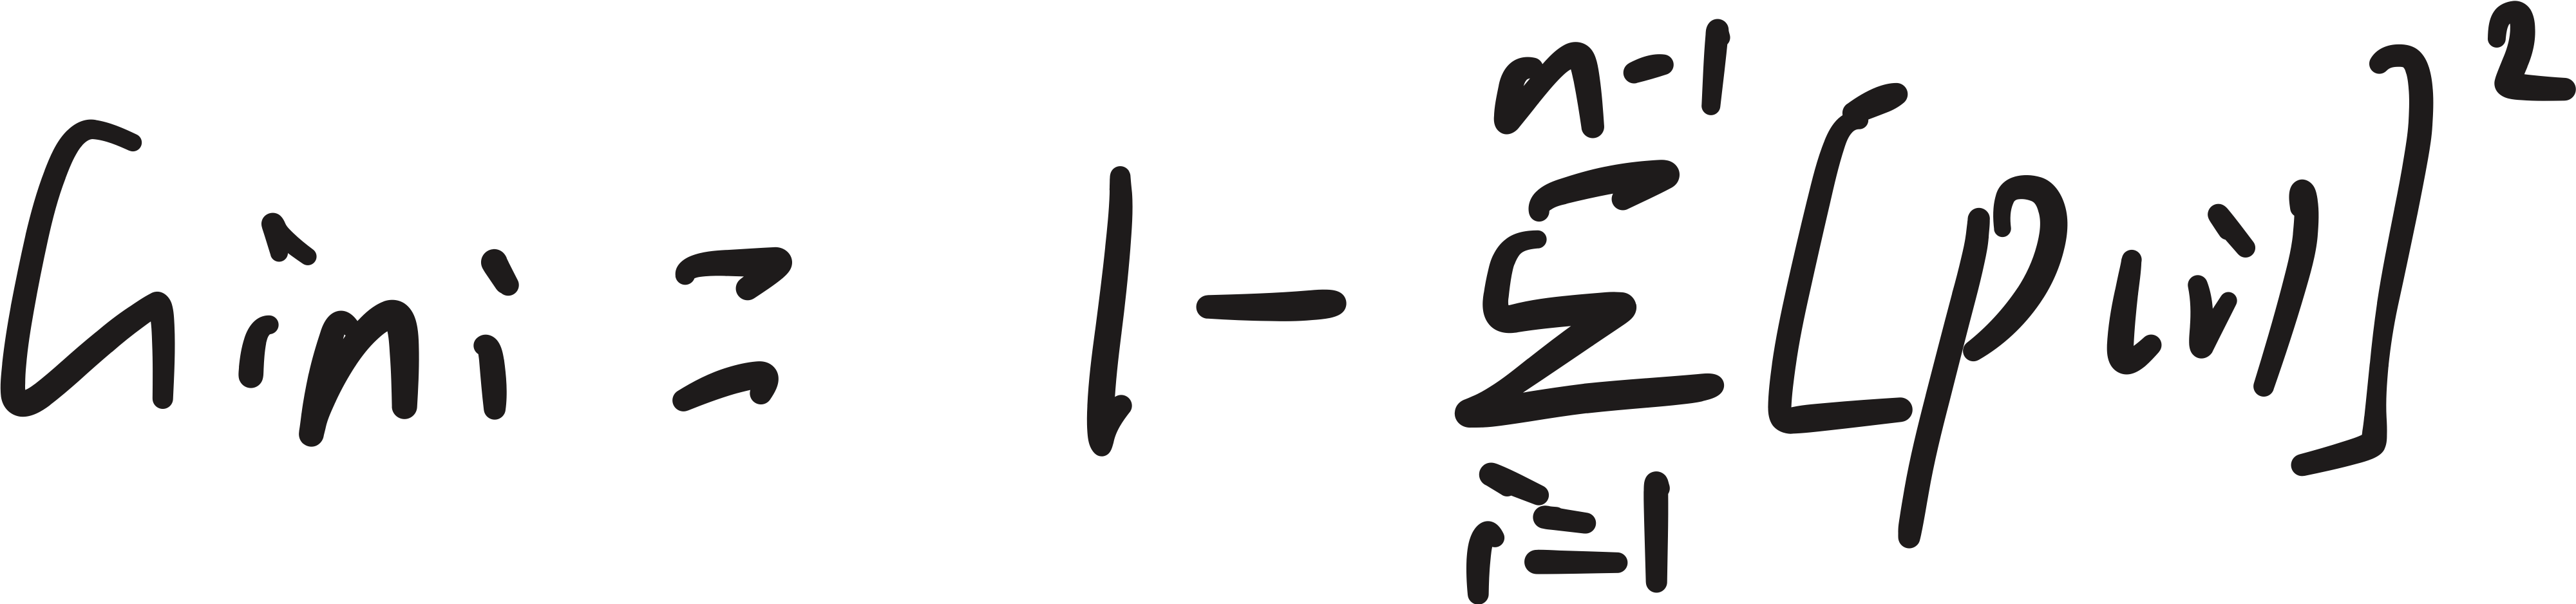

In [6]:
import numpy as np

In [11]:
# 计算一共有哪些标签，以及每个标签下含有数据的个数

y = [1,1,0,1,1,2,2,2,2,3]
_, counts = np.unique(y, return_counts=True)
print(_)
print(counts)

[0 1 2 3]
[1 4 4 1]


In [12]:
# 计算每个标签的概率

probabilities = counts / len(y)
print(probabilities)

[0.1 0.4 0.4 0.1]


In [10]:
# 计算基尼系数

gini = 1

for i in range(len(probabilities)):
    gini -= probabilities[i]**2

print(gini)



0.6599999999999999


In [14]:
# 使用numpy加速运算

gini = 1 - np.sum(probabilities ** 2)
print(gini)

0.6599999999999999


In [15]:
# 1. 手写计算基尼系数
def calculate_gini(y):
    """
    计算一个标签数组 y 的基尼系数
    """
    if len(y) == 0:
        return 0.0

    _, counts = np.unique(y, return_counts=True)

    probabilities = counts / len(y)

    gini = 1.0 - np.sum(probabilities ** 2)
    return gini


In [16]:
# 2. 手写寻找最佳切分点 (决策树核心优化过程)
def find_best_split(X, y):
    """
    遍历所有的特征和切分候选值，找到最佳切分特征索引和切分阈值
    """
    best_gini = float("inf") # 目标是让加权 Gini 最小
    best_feature_idx = None
    best_threshold = None

    n_samples, n_features = X.shape
    current_gini = calculate_gini(y)

    # 遍历每一个特征
    for feature_idx in range(n_features):
        feature_values = X[:, feature_idx]
        # 获取该特征所有可能的值作为候选切分点
        possible_thresholds = np.unique(feature_values)

        # 遍历该特征下的每一个切分阈值
        for threshold in possible_thresholds:
            # 根据 threshold 把数据分为左右两边
            left_mask = feature_values <= threshold
            right_mask = feature_values > threshold

            y_left = y[left_mask]
            y_right = y[right_mask]

            # 如果切分后一边为空，说明没有起到划分作用，跳过
            if len(y_left) == 0 or len(y_right) == 0:
                continue

            # 计算切分后的加权 Gini 系数
            gini_left = calculate_gini(y_left)
            gini_right = calculate_gini(y_right)

            w_left = len(y_left) / n_samples
            w_right = len(y_right) / n_samples
            weighted_gini = w_left * gini_left + w_right * gini_right

            # 如果找到了更小的加权 Gini，更新最佳切分方案
            if weighted_gini < best_gini:
                best_gini = weighted_gini
                best_feature_idx = feature_idx
                best_threshold = threshold

    return best_feature_idx, best_threshold, best_gini




In [17]:
# 3. 验证一下手写代码
if __name__ == "__main__":
    # 创建一份简单的测试数据 (4个样本，2个特征)
    # 特征0: 酒精含量, 特征1: 苹果酸含量
    X_demo = np.array([
        [14.0, 1.5],  # 样本 1
        [13.5, 2.3],  # 样本 2
        [11.0, 3.0],  # 样本 3
        [11.2, 0.9]   # 样本 4
    ])
    # 标签 y: 1 表示高档酒，0 表示普通酒
    y_demo = np.array([1, 1, 0, 0])

    print(f"原始数据的 Gini 系数: {calculate_gini(y_demo):.4f}")

    # 查找最佳切分点
    feat_idx, thresh, g_val = find_best_split(X_demo, y_demo)

    print("\n--- 决策树的最佳切分抉择 ---")
    print(f"最佳切分特征索引: {feat_idx} (特征 {feat_idx})")
    print(f"最佳切分阈值 (Threshold): {thresh}")
    print(f"切分后的加权 Gini 系数: {g_val:.4f}")

原始数据的 Gini 系数: 0.5000

--- 决策树的最佳切分抉择 ---
最佳切分特征索引: 0 (特征 0)
最佳切分阈值 (Threshold): 11.2
切分后的加权 Gini 系数: 0.0000


直接调包

In [18]:
from sklearn.tree import DecisionTreeClassifier, export_text

# 实例化决策树，使用 gini 作为划分标准，最大深度设为 1（只切一刀）
clf = DecisionTreeClassifier(criterion='gini', max_depth=1)
clf.fit(X_demo, y_demo)

# 打印 sklearn 找到的切分规则
tree_rules = export_text(clf, feature_names=['酒精含量', '苹果酸'])
print("\n--- Scikit-learn 生成的规则 ---")
print(tree_rules)


--- Scikit-learn 生成的规则 ---
|--- 酒精含量 <= 12.35
|   |--- class: 0
|--- 酒精含量 >  12.35
|   |--- class: 1



用大一点的数据集来做，例如泰坦尼克号

In [19]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import accuracy_score


In [20]:
# 1. 获取真实大数据集：泰坦尼克号 (Titanic)
titanic = fetch_openml('titanic', version=1, as_frame=True, parser='auto')
df = titanic.frame
print(df.head())

   pclass survived                                             name     sex  \
0       1        1                    Allen, Miss. Elisabeth Walton  female   
1       1        1                   Allison, Master. Hudson Trevor    male   
2       1        0                     Allison, Miss. Helen Loraine  female   
3       1        0             Allison, Mr. Hudson Joshua Creighton    male   
4       1        0  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)  female   

       age  sibsp  parch  ticket      fare    cabin embarked boat   body  \
0  29.0000      0      0   24160  211.3375       B5        S    2    NaN   
1   0.9167      1      2  113781  151.5500  C22 C26        S   11    NaN   
2   2.0000      1      2  113781  151.5500  C22 C26        S  NaN    NaN   
3  30.0000      1      2  113781  151.5500  C22 C26        S  NaN  135.0   
4  25.0000      1      2  113781  151.5500  C22 C26        S  NaN    NaN   

                         home.dest  
0                     St Louis,

In [21]:
# 挑选几个最核心的实用特征
features = ['pclass', 'sex', 'age', 'fare']
X = df[features].copy()
y = df['survived'].astype(int).values # 1: 存活, 0: 未存活


In [22]:
X

,pclass,sex,age,fare
0,1,female,29.0000,211.3375
1,1,male,0.9167,151.5500
2,1,female,2.0000,151.5500
3,1,male,30.0000,151.5500
4,1,female,25.0000,151.5500
...,...,...,...,...
1304,3,female,14.5000,14.4542
1305,3,female,NaN,14.4542
1306,3,male,26.5000,7.2250
1307,3,male,27.0000,7.2250


In [23]:
# 简单预处理：将性别转换为数字 (男:1, 女:0)，并填补缺省值
X['sex'] = (X['sex'] == 'male').astype(int)
X['age'] = X['age'].fillna(X['age'].median())
X['fare'] = X['fare'].fillna(X['fare'].median())
X_mat = X.values

print(f"样本总数: {X_mat.shape[0]} 行, 特征数: {X_mat.shape[1]} 个\n")


样本总数: 1309 行, 特征数: 4 个



In [24]:
# 2. 用手写的 Gini 函数，看看根节点第一刀会切在哪里！
def calculate_gini(y):
    if len(y) == 0:
        return 0.0
    _, counts = np.unique(y, return_counts=True)
    probabilities = counts / len(y)
    return 1.0 - np.sum(probabilities ** 2)

def find_best_split(X, y):
    best_gini = float("inf")
    best_feature_idx = None
    best_threshold = None
    n_samples, n_features = X.shape

    for feature_idx in range(n_features):
        feature_values = X[:, feature_idx]
        possible_thresholds = np.unique(feature_values)

        # 如果特征取值太多（比如连续变量），可以采样加速，这里遍历全部
        for threshold in possible_thresholds:
            left_mask = feature_values <= threshold
            right_mask = feature_values > threshold

            y_left, y_right = y[left_mask], y[right_mask]
            if len(y_left) == 0 or len(y_right) == 0:
                continue

            w_left, w_right = len(y_left) / n_samples, len(y_right) / n_samples
            weighted_gini = w_left * calculate_gini(y_left) + w_right * calculate_gini(y_right)

            if weighted_gini < best_gini:
                best_gini = weighted_gini
                best_feature_idx = feature_idx
                best_threshold = threshold

    return best_feature_idx, best_threshold, best_gini



In [25]:
# 运行手写算法评估 1309 条数据
feat_idx, thresh, g_val = find_best_split(X_mat, y)
print("=== 🌟 手写 Gini 算法在 1309 条真实数据上的决策 ===")
print(f"根节点最佳切分特征: {features[feat_idx]}")
print(f"最佳切分阈值 (Threshold): {thresh}")
print(f"切分后的加权 Gini 系数: {g_val:.4f}\n")

# -------------------------------------------------------------
# 3. 划分数据集并用 Sklearn 构建完整决策树
# -------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X_mat, y, test_size=0.2, random_state=42)

# 限制树的最大深度为 3，防止大树过拟合
clf = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# 测试集准确率
y_pred = clf.predict(X_test)
print(f"决策树在测试集上的预测准确率: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

# 打印生成的树状判断逻辑
print("=== 🌲 训练出的决策树逻辑图解 ===")
rules = export_text(clf, feature_names=features)
print(rules)

=== 🌟 手写 Gini 算法在 1309 条真实数据上的决策 ===
根节点最佳切分特征: sex
最佳切分阈值 (Threshold): 0.0
切分后的加权 Gini 系数: 0.3402

决策树在测试集上的预测准确率: 77.10%

=== 🌲 训练出的决策树逻辑图解 ===
|--- sex <= 0.50
|   |--- pclass <= 2.50
|   |   |--- fare <= 32.09
|   |   |   |--- class: 1
|   |   |--- fare >  32.09
|   |   |   |--- class: 1
|   |--- pclass >  2.50
|   |   |--- fare <= 23.35
|   |   |   |--- class: 1
|   |   |--- fare >  23.35
|   |   |   |--- class: 0
|--- sex >  0.50
|   |--- age <= 9.50
|   |   |--- pclass <= 2.50
|   |   |   |--- class: 1
|   |   |--- pclass >  2.50
|   |   |   |--- class: 0
|   |--- age >  9.50
|   |   |--- pclass <= 1.50
|   |   |   |--- class: 0
|   |   |--- pclass >  1.50
|   |   |   |--- class: 0



In [29]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.datasets import fetch_openml
# from sklearn.model_selection import train_test_split
# from sklearn.tree import DecisionTreeClassifier, plot_tree
#
# # 1. 加载并预处理泰坦尼克号数据
# titanic = fetch_openml('titanic', version=1, as_frame=True, parser='auto')
# df = titanic.frame
#
# features = ['pclass', 'sex', 'age', 'fare']
# X = df[features].copy()
# y = df['survived'].astype(int).values
#
# X['sex'] = (X['sex'] == 'male').astype(int)
# X['age'] = X['age'].fillna(X['age'].median())
# X['fare'] = X['fare'].fillna(X['fare'].median())
#
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#
# # 2. 训练决策树模型
# feature_names = ['Pclass', 'Sex (1:M, 0:F)', 'Age', 'Fare']
# class_names = ['Died (0)', 'Survived (1)']
#
# clf = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
# clf.fit(X_train, y_train)
#
# import dtreeviz
#
# # 关键修正：确保 X_train 和 y_train 传给 dtreeviz 时格式对齐
# # 可以使用 .values 或者 np.asarray() 转换为纯 numpy 格式
# viz_model = dtreeviz.model(
#     model=clf,
#     X_train=X_train.values if isinstance(X_train, pd.DataFrame) else X_train,
#     y_train=np.asarray(y_train),
#     target_name="survived",
#     feature_names=feature_names,
#     class_names=class_names
# )
#
# # 生成并显示图像
# v = viz_model.view()
# v.show()

/Users/ikunchuan/miniconda3/envs/image_recognition/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
